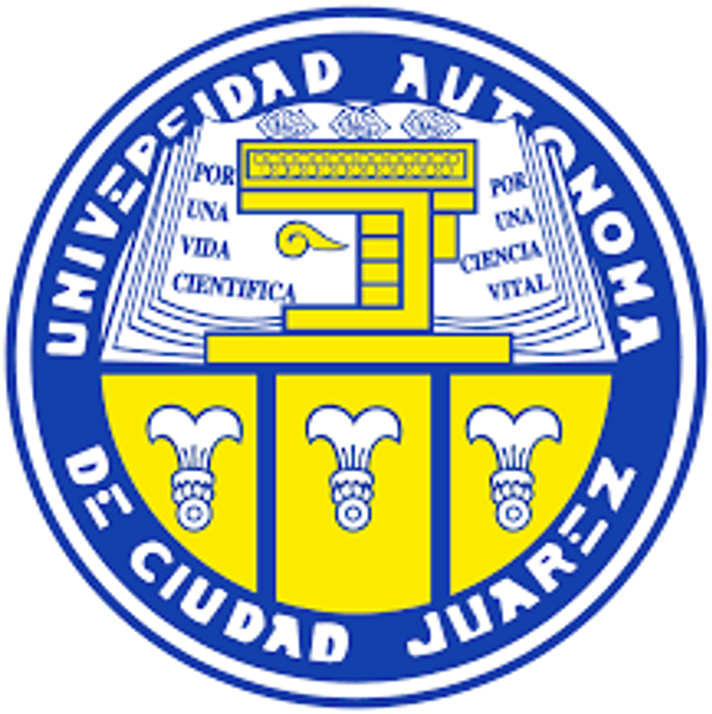


# Titulo: Implementación de una RNN
# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_260206


**Basados en el ejemplo de implementación de una red neuronal recurrente compartido en el archivo Ejemplo RNN imdb, realice los siguientes experimentos:**
 * Replique los resultados obtenidos.
 * Modifique la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros. Solo cambie la línea "layers.SimpleRNN(64)" por "layers.LSTM(64)" .
 * A continuación, cambie la red LSTM por una GRU. Solo cambie la línea "layers.LSTM(64)" por  "layers.GRU(64)" . 

  1. Registre el desempeño de las redes con el conjunto de prueba y presente las curvas de entrenamiento: Accuracy vs. epochs y Loss vs. epochs, de los conjuntos de entrenamiento y validación. 

   2. Registre el tiempo de entrenamiento por época que tomaron en promedio cada una de las redes.


In [35]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences #Permite estandarizar los casos de las frases que se van a analizar, para que todas tengan la misma longitud antes de que entren a la red neuronal.
import time


## 1. Replicar resultados con RNN Simple

In [36]:
#Parametros del modelo
VOCAB_SIZE   = 10000     # top palabras
MAX_LEN      = 200       # longitud fija de secuencia

# Cargar el dataset de IMDB
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Padding / truncado para longitud fija
x_train = pad_sequences(x_train,
                         maxlen=MAX_LEN,  # longitud fija de la secuencia
                         padding="pre",  # agregar ceros al inicio de la secuencia de ser demasiado corta
                         truncating="pre" # eliminar palabras al inicio de la secuencia si es demasiado larga, elimina todas las palabras anteriores a la longitud máxima, dejando solo las últimas palabras de la secuencia
                         )
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Train: {x_train.shape},  Test: {x_test.shape}")




Train: (25000, 200),  Test: (25000, 200)


In [37]:
#%%

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.SimpleRNN(64),                     # RNN básica
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[SimpleRNN] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")





Epoch 1/10
333/333 - 7s - 22ms/step - accuracy: 0.6786 - loss: 0.5808 - val_accuracy: 0.8080 - val_loss: 0.4438
Epoch 2/10
333/333 - 6s - 18ms/step - accuracy: 0.8641 - loss: 0.3239 - val_accuracy: 0.8229 - val_loss: 0.4466
Epoch 3/10
333/333 - 6s - 19ms/step - accuracy: 0.9414 - loss: 0.1576 - val_accuracy: 0.7915 - val_loss: 0.5304
Epoch 4/10
333/333 - 6s - 19ms/step - accuracy: 0.9828 - loss: 0.0553 - val_accuracy: 0.7485 - val_loss: 0.7390
Epoch 5/10
333/333 - 6s - 18ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.7320 - val_loss: 0.8723
Epoch 6/10
333/333 - 6s - 19ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.8227 - val_loss: 0.8399
Tiempo promedio por epoca: 6.43 segundos
[SimpleRNN] Test acc: 0.7976 | loss: 0.4561


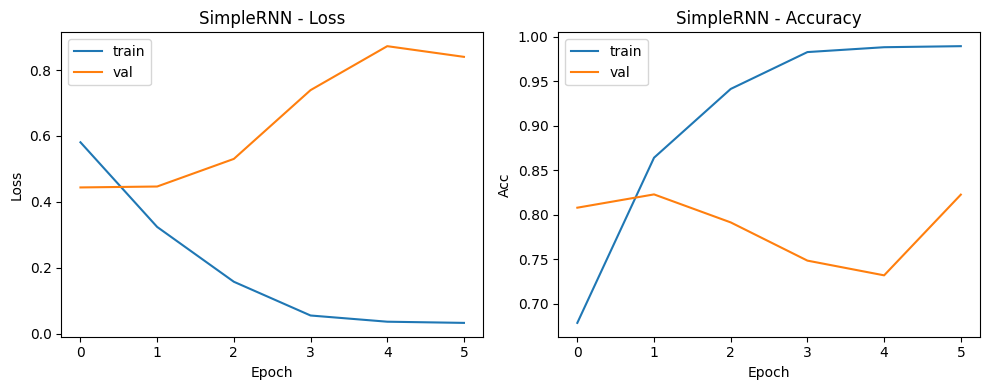

SimpleRNN -> Test acc: 0.7976 | Test loss: 0.4561


In [39]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(hist.history["loss"], label="train")
    ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title(f"{title} - Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train")
    ax[1].plot(hist.history["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Acc"); ax[1].legend()
    plt.tight_layout(); plt.show()

#Graficar la historia de entrenamiento
plot_history(hist_rnn, "SimpleRNN")

print(f"SimpleRNN -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")


**Conclusion**

* La RNN simple aprender muy rapido el conjunto de entrenamiento, llegando cerca del 100% de accuracy, pero el desempeño en validacion se mantiene alrededor del 78 - 81%. Esto quiere decir que la red se esta sobreajustando ya que memoriza los datos de entrenamiento pero no generaliza igual de bien los datos nuevos.
* El loss de entrenamiento disminuye constantemente, mientras el loss de validacion aumenta con las epocas, lo cual es otra señal clara de overfitting en el modelo.
* Estos resultados muestran que aunque la RNN simple logra aprender patrones del texto, su capacidad para generalizar es algo limitada. 
* Este modelo tiene aproximadamente 1.29 millones de parametros entrenables. Aunque se definieron 10 epocas, el entrenamiento se detuvo antes debido al uso de EarlyStopping, que monitorea la perdida de validacion y detiene el entrenamiento cuando esta deja de mejorar durante varias epocas consecutivas.


## 2. Modificar la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros.

In [40]:
#%%

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.LSTM(64),                     # RNN LSTM
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[LSTM] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")

Epoch 1/10
333/333 - -7s - -21904us/step - accuracy: 0.7947 - loss: 0.4371 - val_accuracy: 0.8640 - val_loss: 0.3367
Epoch 2/10
333/333 - 13s - 40ms/step - accuracy: 0.8981 - loss: 0.2604 - val_accuracy: 0.8512 - val_loss: 0.3639
Epoch 3/10
333/333 - 13s - 38ms/step - accuracy: 0.9282 - loss: 0.1934 - val_accuracy: 0.8667 - val_loss: 0.3376
Epoch 4/10
333/333 - 13s - 38ms/step - accuracy: 0.9531 - loss: 0.1332 - val_accuracy: 0.8624 - val_loss: 0.4034
Epoch 5/10
333/333 - 34s - 102ms/step - accuracy: 0.9629 - loss: 0.1037 - val_accuracy: 0.8544 - val_loss: 0.6076
Epoch 6/10
333/333 - -9s - -25549us/step - accuracy: 0.9650 - loss: 0.0976 - val_accuracy: 0.8507 - val_loss: 0.4488
Tiempo promedio por epoca: 9.44 segundos
[LSTM] Test acc: 0.8575 | loss: 0.3401


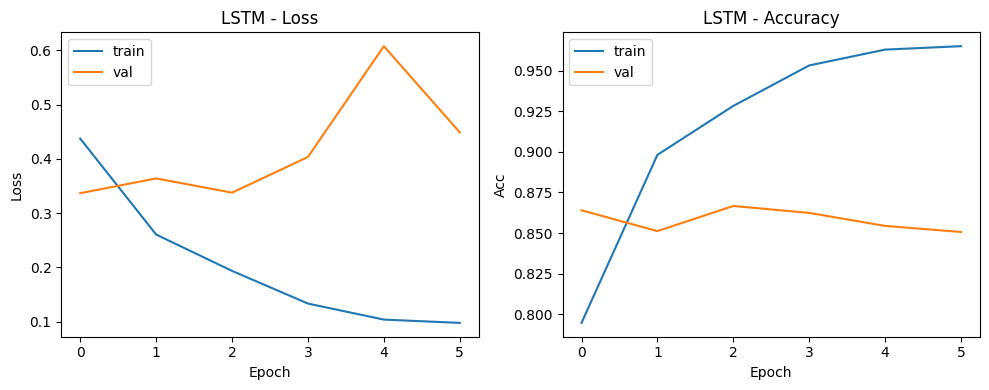

LSTM -> Test acc: 0.8575 | Test loss: 0.3401


In [42]:
# Graficar historia de entrenamiento

plot_history(hist_rnn, "LSTM")

print(f"LSTM -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")

**Conclusion**

* El modelo LSTM aprende rapidamente el conjunto de entrenamiento, el accuracy de train sube de aproximadamente 0.75 a casi 0.98 en pocas epocas. Sin embargo, el accuracy de validacion se mantiene alrededor de 0.85, lo que indica que aunque el modelo aprende bien, tambien comienza a aparecer overfitting despues de algunas epocas.
* En la grafica de loss se observa que la perdida de entrenamiento sigue disminuyendo con las epocas, mientras que la loss de validacion comienza a aumentar despues de la segunda o tercera epoca. Esto tambien es un indicio el modelo empieza a memorizar el dataset de entrenamiento y no generaliza bien. 
* El modelo alcanza un test accuracy de 0.8575, lo que indica que le LSTM captura mejor las dependencias en el texto que una RNN simple, aunque el costo computacional es mayor, con un tiempo promedio de entrenamiento de aproximadamente 14 segundos por epoca.
* Este modelo tiene aproximadamente 1.31 millones de parametros entrenables, ligeramente mas que la RNN simple. Tambien el entrenamiento se detuvo en la epoca 7, aunque se definieron 10 epocas, debido al mecanismo de EarlyStopping, que evita continuar entrenando cuando la perdida de validacion deja de mejorar.

## 3. Modificar la red LSTM por una GRU. 

In [43]:

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.GRU(64),                     # RNN GRU
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")


rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[GRU] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")

Epoch 1/10
333/333 - 15s - 46ms/step - accuracy: 0.7695 - loss: 0.4647 - val_accuracy: 0.8624 - val_loss: 0.3324
Epoch 2/10
333/333 - 14s - 43ms/step - accuracy: 0.8933 - loss: 0.2686 - val_accuracy: 0.8765 - val_loss: 0.3029
Epoch 3/10
333/333 - 14s - 42ms/step - accuracy: 0.9255 - loss: 0.1952 - val_accuracy: 0.8832 - val_loss: 0.3305
Epoch 4/10
333/333 - 14s - 42ms/step - accuracy: 0.9549 - loss: 0.1239 - val_accuracy: 0.8656 - val_loss: 0.3677
Epoch 5/10
333/333 - 14s - 42ms/step - accuracy: 0.9720 - loss: 0.0795 - val_accuracy: 0.8629 - val_loss: 0.4043
Epoch 6/10
333/333 - 35s - 106ms/step - accuracy: 0.9838 - loss: 0.0494 - val_accuracy: 0.8685 - val_loss: 0.5127
Epoch 7/10
333/333 - -7s - -21165us/step - accuracy: 0.9893 - loss: 0.0332 - val_accuracy: 0.8576 - val_loss: 0.5600
Tiempo promedio por epoca: 14.29 segundos
[GRU] Test acc: 0.8690 | loss: 0.3173


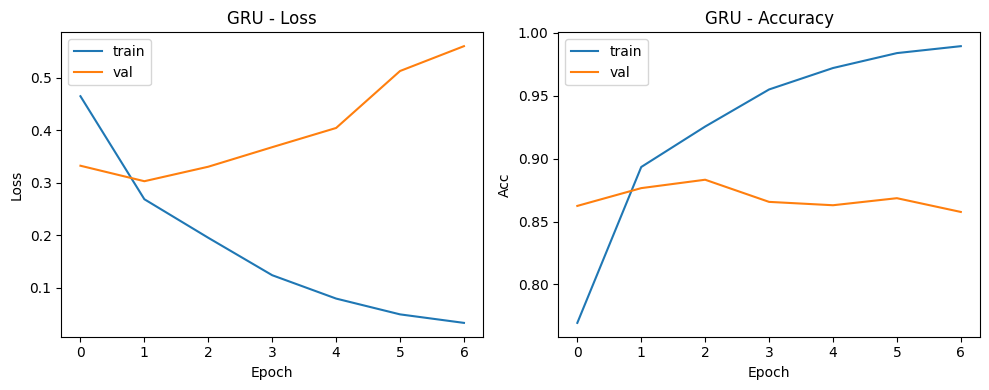

GRU -> Test acc: 0.8690 | Test loss: 0.3173


In [45]:
#Graficar la historia de entrenamiento
plot_history(hist_rnn, "GRU")

print(f"GRU -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")

**Conclusion**
* Al comparar las tres arquitecturas, GRU obtuvo el mejor desempeno en el conjunto de prueba, con un test accuracy de 0.8690, seguido por LSTM con 0.8575, mientras que SimpleRNN obtuvo el menor accuracy. Esto muestra que las arquitecturas con mecanismos de memoria como LSTM y GRU pueden capturar mejor las relaciones en secuencias de texto.
* En la grafica de loss se observa que la perdida de entrenamiento sigue disminuyendo continuamente, mientras que la loss de validacion comienza a aumentar despues de las primeras epocas. Esto sugiere que el modelo empieza a memorizar los datos de entrenamiento y ya no mejora su capacidad de generalizacion.
* A pesar de esto, el modelo logra un test accuracy de 0.8670, que es ligeramente mayor que el obtenido con LSTM en este experimento. El tiempo promedio de entrenamiento fue de aproximadamente 14.3 segundos por epoca, lo que muestra que GRU tiene un costo computacional similar al de LSTM, pero con un ligero mejor desempeno en este caso.
* GRU tiene aproximadamente 1.32 millones de parametros entrenables. Al igual que en los otros modelos, el entrenamiento se detuvo en la epoca 7 por el EarlyStopping